In [1]:
# Import libraries for expanded evaluation metrics and price-band analysis
import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

##### Model Leaderboard (All Models, Same 72 Features)

In [2]:
full_comparison_df = pd.read_csv("output/full_feature_model_comparison.csv")
boosting_df = pd.read_csv("output/week7_advanced_model_metrics.csv")

overall_leaderboard = pd.concat([full_comparison_df, boosting_df], ignore_index=True)
overall_leaderboard = overall_leaderboard.sort_values("Test_R2", ascending=False).reset_index(drop=True)
overall_leaderboard.to_csv("output/overall_leaderboard.csv", index=False)
overall_leaderboard

,Model,Train_R2,Test_R2,MAE,RMSE,MAPE,MdAPE
0,"XGBoost (best: {'learning_rate': 0.1, 'max_dep...",0.873451,0.850876,203882.610439,329486.146891,18.585886,12.152673
1,"LightGBM (best: {'learning_rate': 0.1, 'max_de...",0.850065,0.837123,217549.436707,344344.728159,20.068749,13.578526
2,Random Forest (full features),0.750698,0.719982,288413.857532,451499.429228,28.870829,16.986346
3,Linear Regression (full features),0.657222,0.659080,344440.908780,498184.272328,34.050761,24.748287
4,Decision Tree (full features),0.643482,0.633042,342442.226609,516858.912459,35.816058,21.281381


In [3]:
# Load the same time-based split, and refit the best model from Week 7 so we have predictions to evaluate
from xgboost import XGBRegressor

train_df = pd.read_csv("output/train.csv")
test_df = pd.read_csv("output/test.csv")

X_train_full = train_df.drop(columns=["ClosePrice"])
y_train = train_df["ClosePrice"]
X_test_full = test_df.drop(columns=["ClosePrice"])
y_test = test_df["ClosePrice"]

# best params found during Week 7 tuning
best_model = XGBRegressor(max_depth=7, learning_rate=0.1, n_estimators=300, random_state=42, n_jobs=-1)
best_model.fit(X_train_full, y_train)

y_pred = best_model.predict(X_test_full)
print("Predictions generated for", len(y_pred), "test rows")

Predictions generated for 12434 test rows


In [4]:
# MAPE: average percentage error. MdAPE: median percentage error (more robust to outliers than MAPE)
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape_val = mape(y_test, y_pred)
mdape_val = mdape(y_test, y_pred)

print("Overall Test Metrics")
print("---------------------")
print(f"R²:     {r2:.4f}")
print(f"MAE:    ${mae:,.0f}")
print(f"RMSE:   ${rmse:,.0f}")
print(f"MAPE:   {mape_val:.2f}%")
print(f"MdAPE:  {mdape_val:.2f}%")

Overall Test Metrics
---------------------
R²:     0.8509
MAE:    $203,883
RMSE:   $329,486
MAPE:   18.59%
MdAPE:  12.15%


In [5]:
# Split test set into price bands (quintiles) based on actual sale price, to see where the model performs best/worst
results = pd.DataFrame({"y_true": y_test.values, "y_pred": y_pred})
results["abs_pct_error"] = np.abs((results["y_true"] - results["y_pred"]) / results["y_true"]) * 100

results["price_band"] = pd.qcut(
    results["y_true"],
    q=5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"]
)

results.head()

,y_true,y_pred,abs_pct_error,price_band
0,2185000.0,1.889257e+06,13.535132,Q5 (highest)
1,500000.0,7.621358e+05,52.427163,Q1 (lowest)
2,1500000.0,1.817323e+06,21.154842,Q4
3,3885000.0,3.427347e+06,11.780000,Q5 (highest)
4,3885000.0,3.513654e+06,9.558443,Q5 (highest)


In [6]:
# Compute R², MAE, MAPE, MdAPE separately within each price band
band_metrics = []
for band in results["price_band"].cat.categories:
    band_df = results[results["price_band"] == band]
    band_metrics.append({
        "Price_Band": band,
        "Count": len(band_df),
        "Price_Range": f"${band_df['y_true'].min():,.0f} - ${band_df['y_true'].max():,.0f}",
        "MAE": mean_absolute_error(band_df["y_true"], band_df["y_pred"]),
        "MAPE": band_df["abs_pct_error"].mean(),
        "MdAPE": band_df["abs_pct_error"].median(),
    })

band_metrics_df = pd.DataFrame(band_metrics)
band_metrics_df

,Price_Band,Count,Price_Range,MAE,MAPE,MdAPE
0,Q1 (lowest),2509,"$26,000 - $580,000",91866.412628,27.090792,13.009268
1,Q2,2478,"$580,235 - $805,000",115754.088882,16.662458,10.858949
2,Q3,2473,"$806,000 - $1,115,000",154253.045519,16.439090,11.041479
3,Q4,2487,"$1,116,000 - $1,675,525",210834.406602,15.470881,11.811826
4,Q5 (highest),2487,"$1,677,000 - $3,885,000",447097.694361,17.171932,14.251526


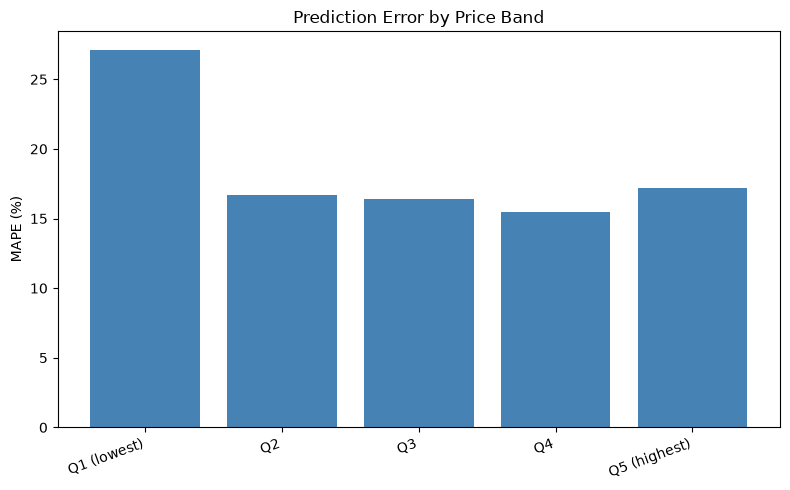

In [7]:
# Visualize how error rate changes across price bands
plt.figure(figsize=(8, 5))
plt.bar(band_metrics_df["Price_Band"], band_metrics_df["MAPE"], color="steelblue")
plt.ylabel("MAPE (%)")
plt.title("Prediction Error by Price Band")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

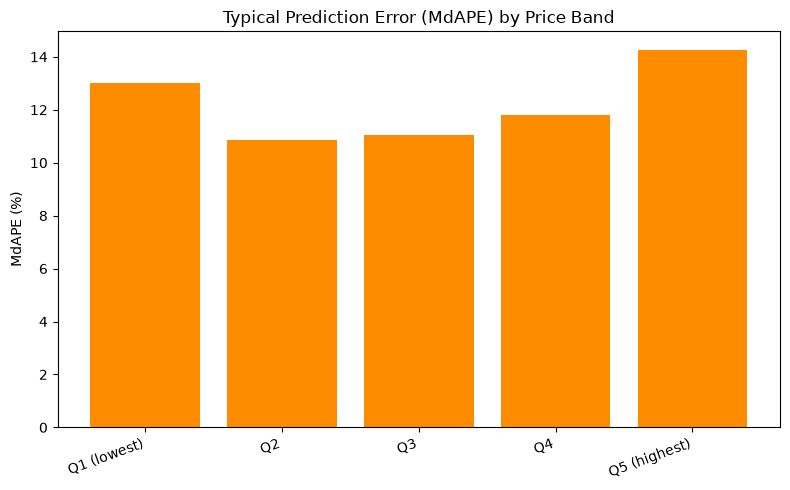

In [9]:
# Visualize typical (median) percent error across price bands
plt.figure(figsize=(8, 5))
plt.bar(band_metrics_df["Price_Band"], band_metrics_df["MdAPE"], color="darkorange")
plt.ylabel("MdAPE (%)")
plt.title("Typical Prediction Error (MdAPE) by Price Band")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [11]:
# Combine overall metrics into a single-row summary table
overall_summary = pd.DataFrame([{
    "Segment": "Overall",
    "Count": len(y_test),
    "R2": r2,
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape_val,
    "MdAPE": mdape_val,
}])
overall_summary

,Segment,Count,R2,MAE,RMSE,MAPE,MdAPE
0,Overall,12434,0.850876,203882.610439,329486.146891,18.585886,12.152673


In [12]:
# Combine overall metrics with per-price-band metrics into a single summary table for export
band_summary = band_metrics_df.rename(columns={"Price_Band": "Segment"})[["Segment", "Count", "MAE", "MAPE", "MdAPE"]]
metrics_summary = pd.concat([overall_summary.drop(columns=["RMSE"]), band_summary], ignore_index=True)
metrics_summary

,Segment,Count,R2,MAE,MAPE,MdAPE
0,Overall,12434,0.850876,203882.610439,18.585886,12.152673
1,Q1 (lowest),2509,NaN,91866.412628,27.090792,13.009268
2,Q2,2478,NaN,115754.088882,16.662458,10.858949
3,Q3,2473,NaN,154253.045519,16.439090,11.041479
4,Q4,2487,NaN,210834.406602,15.470881,11.811826
5,Q5 (highest),2487,NaN,447097.694361,17.171932,14.251526


In [13]:
# Save the full metrics summary (overall + by price band) as the Week 8 deliverable
metrics_summary.to_csv("output/metrics_summary.csv", index=False)
print("Saved output/metrics_summary.csv")

Saved output/metrics_summary.csv


#### Insights: Model Leaderboard and Price-Band Performance

- **Model leaderboard (same 72 features across all models):** With every model evaluated on identical inputs, **XGBoost is the clear winner** — R² 0.8509, MAPE 18.59%, MdAPE 12.15% — followed by LightGBM (R² 0.8371, MdAPE 13.58%). Random Forest, Linear Regression, and Decision Tree all trail well behind (R² 0.63–0.72, MdAPE 17–25%), confirming that gradient boosting's sequential error-correction meaningfully outperforms bagging and single-tree/linear approaches on this data, even once every model has access to the same location-aware feature set.

- **Overall best-model performance:** XGBoost achieved an R² of 0.85, MAPE of 18.59%, and MdAPE of 12.15% on the held-out test month.

- **Price-band error (MAE, MAPE, MdAPE by quintile):** R² is intentionally excluded at the price-band level — it becomes unstable and misleading over narrow price ranges (variance within a band is small, so R² can swing sharply even when absolute errors are reasonable). MAE, MAPE, and MdAPE are more reliable here.

  | Band | Count | MAE | MAPE | MdAPE |
  |---|---|---|---|---|
  | Q1 (lowest, ~$26K–580K) | 2,509 | $91,866 | 27.09% | 13.01% |
  | Q2 | 2,478 | $115,754 | 16.66% | 10.86% |
  | Q3 (~$806K–1.115M) | 2,473 | $154,253 | 16.44% | 11.04% |
  | Q4 | 2,487 | $210,834 | 15.47% | 11.81% |
  | Q5 (highest, ~$1.68M–3.885M) | 2,487 | $447,098 | 17.17% | 14.25% |

<br>

- **Best-performing band:** Q4 has the lowest MAPE (15.47%), closely followed by Q3 (16.44%) — the mid-to-upper-mid price range, where the model has the most representative training examples and prices are neither so low that fixed-dollar errors dominate percentage terms, nor so high that luxury-home variability kicks in. Q2 has the lowest MdAPE (10.86%), reinforcing that the middle of the market is where predictions are most typically accurate.

- **Worst-performing band:** Q1 has by far the highest MAPE (27.09%), despite having the lowest MAE ($91,866) — a fixed dollar error is a much larger percentage on a ~$200K home than on a $2M home. Q5 has a more moderate MAPE (17.17%) but by far the largest MAE ($447,098) and the highest MdAPE (14.25%), likely due to fewer luxury-home comps and greater feature variability at the top of the market.

- **Practical takeaway:** Q1 suffers the largest percentage errors, while Q5 suffers the largest dollar errors — the two ends of the price spectrum fail differently. For pricing decisions, this suggests using wider confidence bands (or a dedicated model) for both the lowest- and highest-priced homes, while trusting point estimates most in the $600K–$1.5M range.
